In [1]:
import json

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sb
from lcdb.db._results import ResultSet

In [2]:
NUM_TEST_SEEDS_TO_EXTRAPOLATE_TO = 1
NUM_VALID_SEEDS_TO_EXTRAPOLATE_TO = 1
NUM_WORKFLOW_SEEDS_TO_EXTRAPOLATE_TO = 1
NUM_CONFIGS_TO_EXTRAPOLATE_TO = 10**2

DATASET_BLACKLIST = []

In [26]:
rs = ResultSet.concat([
    ResultSet.read_jsonl(f"../surf/snellius/data/{k}.jsonl")
    for k in [
        # "lcdb.workflow.sklearn.KNNWorkflow",
        "lcdb.workflow.sklearn.LibLinearWorkflow",
        "lcdb.workflow.sklearn.LibSVMWorkflow",
        # "lcdb.workflow.sklearn.TreesEnsembleWorkflow",
        # "lcdb.workflow.xgboost.XGBoostWorkflow",
        # "lcdb.workflow.keras.DenseNNWorkflow"
    ]
])

In [27]:
d_datasets = sorted(rs.datasets)
d_workflows = sorted(rs.workflows)
print(d_datasets)
print(d_workflows)

[3, 12, 23, 31, 54, 181, 188, 1049, 1067, 1111, 1169, 1457, 1461, 1464, 1468, 1475, 1486, 1487, 1489, 1494, 1515, 1590, 1596, 4134, 4135, 4534, 4538, 4541, 23517, 40498, 40668, 40670, 40685, 40701, 40900, 40975, 40978, 40981, 40982, 40983, 40984, 40996, 41027, 41138, 41142, 41143, 41144, 41145, 41146, 41147, 41150, 41156, 41157, 41158, 41159, 41161, 41162, 41163, 41164, 41165, 41166, 41167, 41168, 41169, 42732, 42733, 42734, 42742, 42746, 42769]
['lcdb.workflow.sklearn.LibLinearWorkflow', 'lcdb.workflow.sklearn.LibSVMWorkflow']


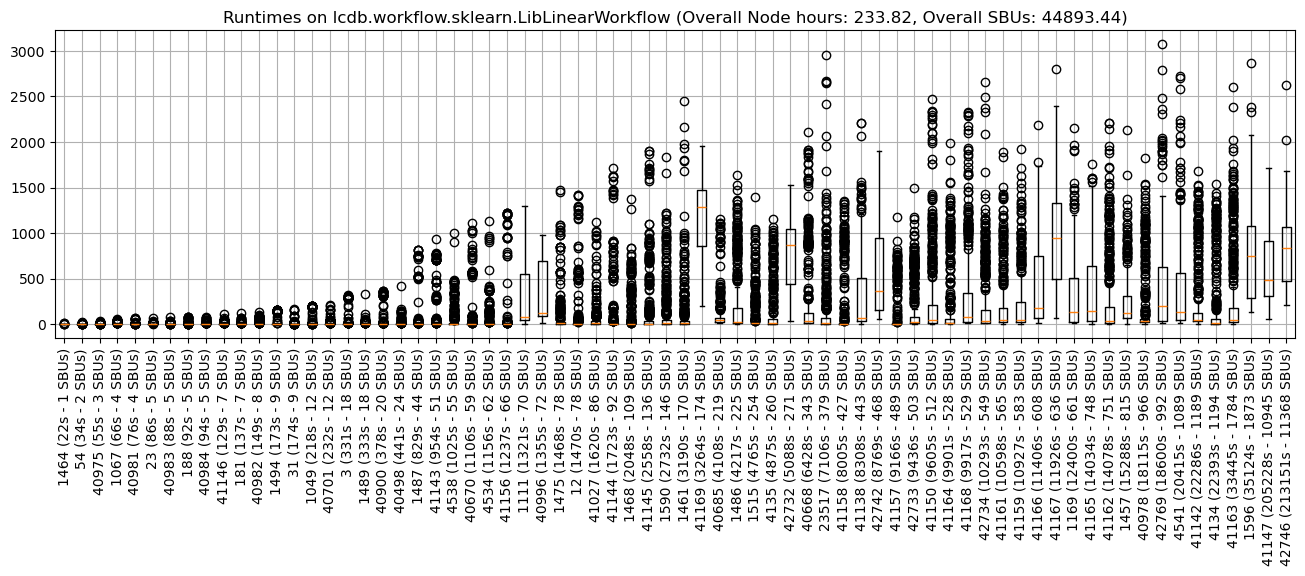

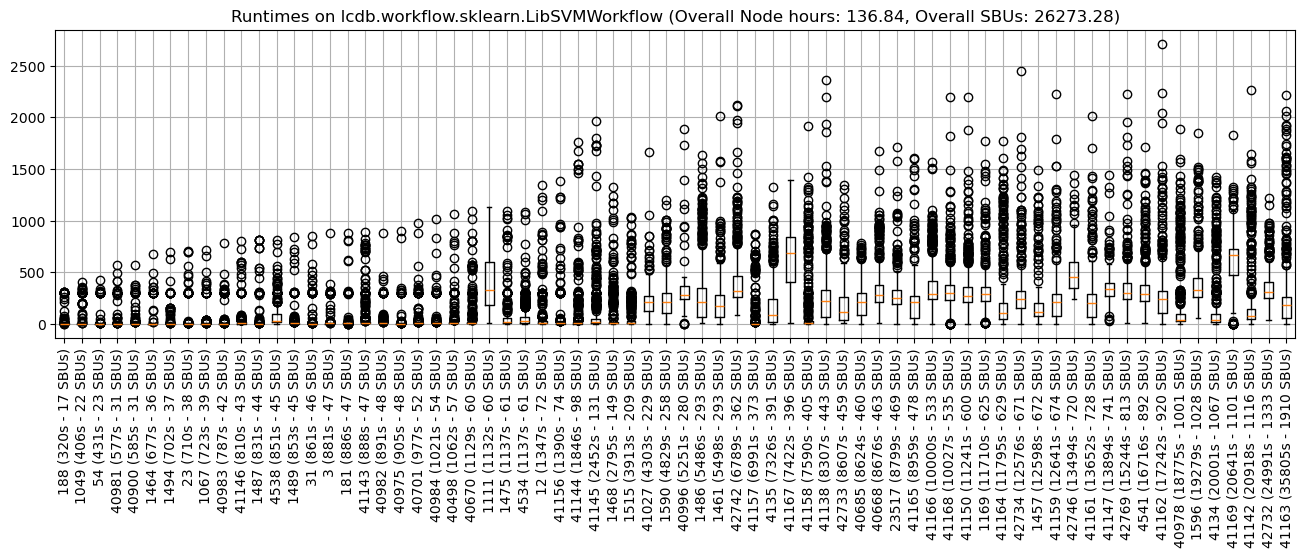

In [28]:
for workflow, rs_workflow in rs.group_by_workflow():
    cpu = "keras" not in workflow
    fig, ax = plt.subplots(figsize=(16, 4))
    
    # compute runtimes per config
    runtimes_per_dataset = []
    for dataset in d_datasets:
        rs_filtered = rs_workflow.filter_datasets(dataset)
        runtimes_per_dataset.append([r["timestamp_end"] - r["timestamp_start"] for r in rs_filtered["experiment_metadata"]])

    # compute full experiment time for dataset
    node_times_per_dataset = []
    for dataset in d_datasets:
        rs_filtered = rs_workflow.filter_datasets(dataset)
        if len(rs_filtered) > 0:
            node_times_per_dataset.append(int(np.round(max([r["timestamp_end"] for r in rs_filtered["experiment_metadata"]]) - min([r["timestamp_start"] for r in rs_filtered["experiment_metadata"]]))))
        else:
            node_times_per_dataset.append(0)#10 * 3600)

    indices = np.argsort(node_times_per_dataset)
    ax.boxplot([runtimes_per_dataset[i] for i in indices])
    
    ax.set_xticklabels([f"{d_datasets[i]} ({node_times_per_dataset[i]}s - {int(np.round(node_times_per_dataset[i] / 3600 * (192 if cpu else 512)))} SBUs)" for i in indices], rotation=90)
    overall_node_seconds = sum(node_times_per_dataset)
    overall_node_hours = np.round(overall_node_seconds / 3600, 2)
    overall_sbus = np.round(overall_node_hours * (192 if cpu else 512), 2)
    ax.set_title(f"Runtimes on {workflow} (Overall Node hours: {overall_node_hours}, Overall SBUs: {overall_sbus})")
    ax.grid()
    plt.show()

/var/folders/09/js8902gx443ch64n24mk1l800000gn/T/ipykernel_87167/2282129726.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


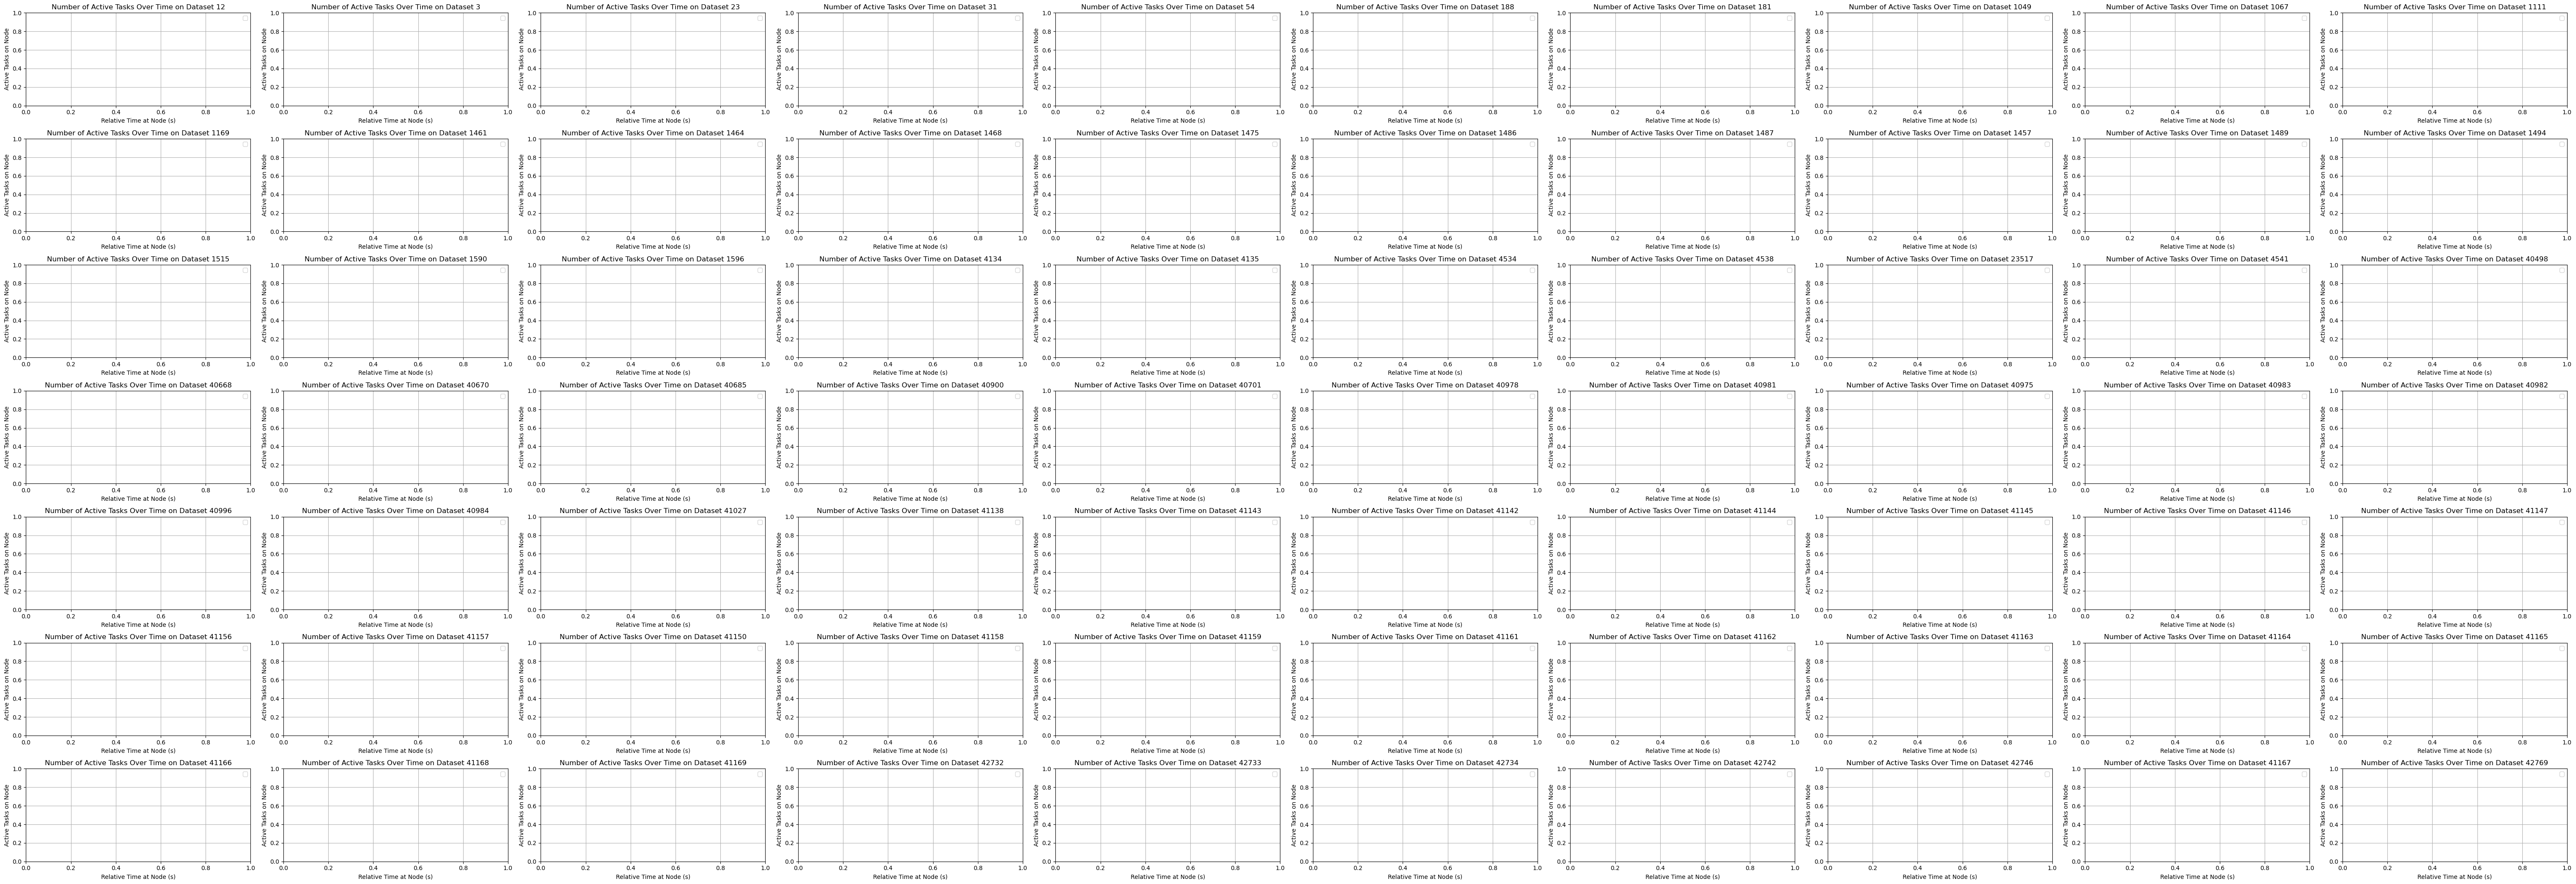

In [29]:
n_cols = 10
n_rows = int(np.ceil(len(rs.datasets) / n_cols))

fig, axs = plt.subplots(n_rows, n_cols, figsize=(1 + n_cols * 6, n_rows * 3))
axs_flattened = axs.flatten()

i = 0
for openmlid, rs_dataset in rs.group_by_dataset():

    ax = axs_flattened[i]
    for workflow, rs_workflow in rs_dataset.group_by_workflow():
        
        if "keras" not in workflow:
            continue

        t_min = min([row["experiment_metadata"]["timestamp_start"] for row in rs_workflow])
        
        # get events
        events = []
        for row in rs_workflow:
            events.append((row["experiment_metadata"]["timestamp_start"] - t_min, 1))
            events.append((row["experiment_metadata"]["timestamp_end"] - t_min, -1))
        events = sorted(events, key=lambda x: x[0])
        
        # build accumulated memory usage over time
        current_memory = 0
        step_points = []   # list of (time, accumulated_memory)
        memory_levels = []
        for t, delta in events:
            current_memory += delta
            step_points.append(t)
            memory_levels.append(current_memory)
        
        ax.step(step_points, memory_levels, where='post', label=workflow)

    i += 1
    
    ax.set_xlabel("Relative Time at Node (s)")
    ax.set_ylabel("Active Tasks on Node")
    ax.set_title(f"Number of Active Tasks Over Time on Dataset {openmlid}")
    ax.legend()
    ax.grid()
fig.tight_layout()
plt.show()

In [30]:
total_runtimes_in_s = np.zeros((len(d_workflows), len(d_datasets)))
num_datapoints = np.zeros((len(d_workflows), len(d_datasets)))
max_memory_requirements = np.zeros((len(d_workflows), len(d_datasets)))
for i, workflow in enumerate(d_workflows):
    for j, openmlid in enumerate(d_datasets):
        rs_filtered = rs.filter_datasets(openmlid).filter_workflows(workflow)
        if len(rs_filtered) == 0:
            total_runtimes_in_s[i, j] = np.nan
            max_memory_requirements[i, j] = np.nan
            num_datapoints[i, j] = 0
        else:
            num_datapoints[i, j] = len(rs_filtered)
            total_runtimes_in_s[i, j] = sum(r["timestamp_end"] - r["timestamp_start"] for r in rs_filtered["experiment_metadata"])
mean_walltime_per_config_in_s = total_runtimes_in_s / np.maximum(1, num_datapoints)
print(mean_walltime_per_config_in_s)

display(pd.DataFrame({
    "dataset:": d_datasets,
    "total walltime in h": ((total_runtimes_in_s[0] / 3600).astype(int)),
    "num_points": num_datapoints[0],
    "mean walltime per config in s": ((mean_walltime_per_config_in_s[0]).astype(int)),
}))

print(f"Total consumed walltime (hours) for the underlying data by workflow ({total_runtimes_in_s.sum() / 3600:.1f} in total):")
for workflow, runtimes_on_datasets, avg_runtime_per_config_for_workflow, datapoints_for_workflow in zip(d_workflows, total_runtimes_in_s, mean_walltime_per_config_in_s, num_datapoints):
    print(f"\t{workflow}: {np.nansum(runtimes_on_datasets) / 3600:.1f}h (for {int(datapoints_for_workflow.sum())} observations. This is an avg runtime of {avg_runtime_per_config_for_workflow.sum() / 3600:.1f}h per config)")

[[  17.58637281   82.6044111     4.4561591     5.59087544    3.78646093
     7.37671704    6.12837912   12.10940115    5.0838074   354.74181496
   310.68619962  236.69735677  101.17506631    2.78186242   69.57843321
    72.110847    214.900142     39.06831331    5.59011931    9.6378842
    84.18782301  107.3001819   752.79527165  176.41186883  113.78264195
    39.41288384   43.8825855   386.03579406  160.17852617   11.80380059
   220.62547473   66.04504593  103.44057001    8.7787425    19.56687132
     4.27420891  176.54522825    3.82055993   11.21791104    4.01457488
     7.03920182  347.46588942   51.93350646  292.42892669  219.44765407
    54.99284066   96.8762937   133.30768998    7.02945138  603.16012836
   264.79122829   55.25168072   72.45553529  130.41373389  209.66826916
   181.60111077  239.30622106  264.10601517  174.52328336  342.49609264
   426.69244423  922.1446575   312.46502901 1178.66859732  746.63261756
   158.06253733  213.3063579   553.34261225  805.21606244  418.54

,dataset:,total walltime in h,num_points,mean walltime per config in s
0,3,2,500.0,17
1,12,11,500.0,82
2,23,0,500.0,4
3,31,0,500.0,5
4,54,0,500.0,3
...,...,...,...,...
65,42733,21,500.0,158
66,42734,29,500.0,213
67,42742,76,500.0,553
68,42746,63,283.0,805


Total consumed walltime (hours) for the underlying data by workflow (2991.4 in total):
	lcdb.workflow.sklearn.LibLinearWorkflow: 1447.3h (for 32642 observations. This is an avg runtime of 3.8h per config)
	lcdb.workflow.sklearn.LibSVMWorkflow: 1544.1h (for 33224 observations. This is an avg runtime of 3.5h per config)


# Extrapolate Compute
We extrapolate
$$\begin{align*}
    \mathbb{E}[\text{runtime on first c configs with first s seed combinations}] &= \mathbb{E}\left[\sum_{\text{workflow}}\sum_\mathit{D}\sum_{\text{seed combination}}\text{ runtime of first c configs of workflow on }\mathit{D}\text{ and seed combination}\right]\\
    &= \sum_{\text{workflow}}\sum_\mathit{D}\sum_{\text{seed combination}}\mathbb{E}\left[\text{ runtime of first c configs of workflow $w$ on }\mathit{D}\text{ and seed combination}\right]\\
    &\approx |\text{\# seed combinations}| \cdot\sum_{\text{workflow}}\sum_\mathit{D}\mathbb{E}\left[\text{ runtime of first c configs of workflow $w$ on }\mathit{D}\text{ and any seed combination}\right]\\
    &\approx c\cdot |\text{\# seed combinations}| \cdot\sum_{\text{workflow}}\sum_\mathit{D}\mathbb{E}\left[\text{any config of workflow $w$ on }\mathit{D}\text{ and any seed combination}\right]
\end{align*}
$$
Here we assume that the expected runtime is the same for all configs and seeds, which is the case if we do not condition on specific such configs and seeds.

This motivates to create a matrix with estimates of mean runtimes, which would be the estimates of the $\mathbb{E}$ in the sum.

Overall expected walltime for 1 test seeds, 1 validation seeds, 1 workflow seeds, and 100 configs overall is 0.7 thsd hours
	Overall expected walltime for lcdb.workflow.sklearn.LibLinearWorkflow is 0.4 thsd hours
	Overall expected walltime for lcdb.workflow.sklearn.LibSVMWorkflow is 0.4 thsd hours


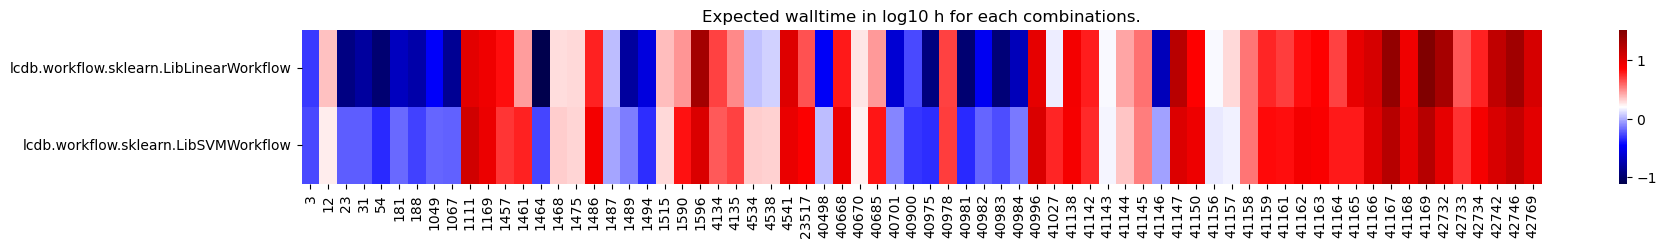

In [31]:
total_expected_entries = NUM_TEST_SEEDS_TO_EXTRAPOLATE_TO * NUM_VALID_SEEDS_TO_EXTRAPOLATE_TO * NUM_WORKFLOW_SEEDS_TO_EXTRAPOLATE_TO * NUM_CONFIGS_TO_EXTRAPOLATE_TO

fig, ax = plt.subplots(1, 1, figsize=(20, 2))

# show data availability
mean_walltime_per_config_in_s = total_runtimes_in_s / np.maximum(1, num_datapoints)
expected_overall_runtimes_in_h = (mean_walltime_per_config_in_s * total_expected_entries) / 3600
sb.heatmap(np.log10(expected_overall_runtimes_in_h), ax=ax, cmap="seismic")
ax.set_xticks(0.5 + np.arange(len(d_datasets)))
ax.set_xticklabels(d_datasets, rotation=90)
ax.set_yticklabels(d_workflows, rotation=0)
ax.set_title(f"Expected walltime in log10 h for each combinations.")

print(f"Overall expected walltime for {NUM_TEST_SEEDS_TO_EXTRAPOLATE_TO} test seeds, {NUM_VALID_SEEDS_TO_EXTRAPOLATE_TO} validation seeds, {NUM_WORKFLOW_SEEDS_TO_EXTRAPOLATE_TO} workflow seeds, and {NUM_CONFIGS_TO_EXTRAPOLATE_TO} configs overall is {np.round(np.sum(expected_overall_runtimes_in_h) / 10**3, 1)} thsd hours")
for i, workflow in enumerate(d_workflows):
    print(f"\tOverall expected walltime for {workflow} is {np.round(np.sum(expected_overall_runtimes_in_h[i]) / 10**3, 1)} thsd hours")

In [32]:
# -------- parameters --------
seed_combos = (
    NUM_TEST_SEEDS_TO_EXTRAPOLATE_TO
    * NUM_VALID_SEEDS_TO_EXTRAPOLATE_TO
    * NUM_WORKFLOW_SEEDS_TO_EXTRAPOLATE_TO  
)

num_configs = NUM_CONFIGS_TO_EXTRAPOLATE_TO

# -------- mean runtime per single run --------
mean_walltime_per_run_s = total_runtimes_in_s / np.maximum(1, num_datapoints)

rows = []

for i, workflow in enumerate(d_workflows):
    
    num_runs = len(d_datasets)
    
    steps_per_run_numeric = seed_combos * num_configs
    
    steps_per_run_display = f"{num_configs} × {seed_combos}"
    
    mean_step = float(np.mean(mean_walltime_per_run_s[i, :]))
    std_step = float(np.std(mean_walltime_per_run_s[i, :]))
    
    walltime_str = f"{mean_step:.2f} ± {std_step:.2f}"
    
    total_walltime_h = (
        num_runs
        * steps_per_run_numeric
        * mean_step   
    ) / 3600.0
    
    rows.append({
        "Type Run (workflow)": workflow,
        "#Runs (datasets)": num_runs,
        "#Steps per Run (configs × seeds)": steps_per_run_display,
        "Wall time per Step (s)": walltime_str,
        "Total walltime (hours)": round(total_walltime_h, 1)
    })

df_sbu = pd.DataFrame(rows)

grand_total = df_sbu["Total walltime (hours)"].sum()

df_sbu.loc["TOTAL"] = [
    "",
    "",
    "",
    "",
    round(grand_total, 1)
]

df_sbu

,Type Run (workflow),#Runs (datasets),#Steps per Run (configs × seeds),Wall time per Step (s),Total walltime (hours)
0,lcdb.workflow.sklearn.LibLinearWorkflow,70,100 × 1,193.42 ± 239.46,376.1
1,lcdb.workflow.sklearn.LibSVMWorkflow,70,100 × 1,180.41 ± 157.30,350.8
TOTAL,,,,,726.9


In [43]:
new_num_runs = 51
a = 10_000
b = 25
new_steps_per_run = a * b
new_steps_per_run_disp_k = "10k × 25"

rows_est = []

for i, workflow in enumerate(d_workflows):
    mean_step = float(np.mean(mean_walltime_per_run_s[i, :]))
    std_step  = float(np.std(mean_walltime_per_run_s[i, :]))

    N = new_num_runs * new_steps_per_run

    total_mean_h = (N * mean_step) / 3600.0
    total_std_h  = (N * std_step)  / 3600.0

    rows_est.append({
        "Type Run (workflow)": workflow,
        "#Runs (datasets)": new_num_runs,
        "#Steps per Run (configs × seeds)": new_steps_per_run_disp_k,
        "Total walltime (hours) ± std": f"{total_mean_h:.1f} ± {total_std_h:.1f}",

    })

df_est = pd.DataFrame(rows_est)

grand_mean = sum(
    float(x.split("±")[0].strip())
    for x in df_est["Total walltime (hours) ± std"]
)
grand_std = sum(
    float(x.split("±")[1].strip())
    for x in df_est["Total walltime (hours) ± std"]
)

df_est.loc["TOTAL", "Type Run (workflow)"] = "TOTAL"
df_est.loc["TOTAL", "Total walltime (hours) ± std"] = f"{grand_mean:.1f} ± {grand_std:.1f}"

df_est

,Type Run (workflow),#Runs (datasets),#Steps per Run (configs × seeds),Total walltime (hours) ± std
0,lcdb.workflow.sklearn.LibLinearWorkflow,51.0,10k × 25,685018.2 ± 848079.6
1,lcdb.workflow.sklearn.LibSVMWorkflow,51.0,10k × 25,638960.8 ± 557090.8
TOTAL,TOTAL,NaN,NaN,1323979.0 ± 1405170.4


# SBU Extrapolation
The above numbers are in CPU hours, but we here assume that a certain number of CPUs must be blocked for each dataset/workflow combination since always a full node is being reserved. Therefore, the number of required SBUs will be higher.

In [34]:
from pathlib import Path
import re

class MemoryBinRetriever:
    def __init__(self, bins_dir="bins_config", default_memory_bin_gb=1.7, strict=False):
        self.bins_dir = Path(bins_dir)
        assert self.bins_dir.exists(), f"Directory not found: {self.bins_dir}"

        self.default_memory_bin_gb = float(default_memory_bin_gb)
        self.strict = strict
        self.memory_by_workflow = {}
        self.missing_pairs = set()

        for csv_path in self.bins_dir.glob("*_bins.csv"):
            key = csv_path.stem.replace("_bins", "").lower()
            df = pd.read_csv(csv_path, header=None, names=["m:openmlid", "memory_bin_gb"])
            df["m:openmlid"] = pd.to_numeric(df["m:openmlid"], errors="coerce")
            df["memory_bin_gb"] = pd.to_numeric(df["memory_bin_gb"], errors="coerce")
            df = df.dropna(subset=["m:openmlid", "memory_bin_gb"])
            df["m:openmlid"] = df["m:openmlid"].astype(int)
            self.memory_by_workflow[key] = dict(zip(df["m:openmlid"], df["memory_bin_gb"].astype(float)))

    @staticmethod
    def _workflow_key(workflow: str) -> str:
        short = workflow.split(".")[-1].replace("Workflow", "")
        return re.sub(r"[^a-z0-9]", "", short.lower())

    def get_memory_bin_for_workflow_dataset_combination(self, workflow, dataset):
        key = self._workflow_key(workflow)
        assert key in self.memory_by_workflow, (
            f"No bins file for workflow {workflow} (expected {key}_bins.csv)"
        )

        ds = int(dataset)
        by_dataset = self.memory_by_workflow[key]

        if ds not in by_dataset:
            if self.strict:
                raise AssertionError(
                    f"Didn't find memory configuration for openmlid {dataset} with workflow {workflow}"
                )
            self.missing_pairs.add((workflow, ds))
            return self.default_memory_bin_gb  # fallback

        return by_dataset[ds]

    def get_memory_bin_matrix(self, workflows, datasets):
        memory_bin_matrix = np.zeros((len(workflows), len(datasets)))
        for i, workflow in enumerate(workflows):
            for j, dataset in enumerate(datasets):
                memory_bin_matrix[i, j] = self.get_memory_bin_for_workflow_dataset_combination(workflow, dataset)
        return memory_bin_matrix

    def report_missing(self, max_show=20):
        if self.missing_pairs:
            ms = sorted(self.missing_pairs)
            print(f"[MemoryBinRetriever] {len(ms)} pairs used fallback={self.default_memory_bin_gb}GB")
            print(ms[:max_show])

retriever = MemoryBinRetriever(
    bins_dir="bins_config",   
    default_memory_bin_gb=1.7,
    strict=False
)
memory_bin_matrix = retriever.get_memory_bin_matrix(d_workflows, d_datasets)
retriever.report_missing()


In [ ]:
new_num_runs = 51
a = 10_000
b = 25
new_steps_per_run = a * b
new_steps_per_run_disp_k = "10k × 25"

max_memory_per_node_in_gb = 336
fractional_billing = False   
CPU_SBU_PER_NODE_HOUR = 192
GPU_SBU_PER_NODE_HOUR = 512

rows_est = []

for i, workflow in enumerate(d_workflows):
    step_s = mean_walltime_per_run_s[i, :].astype(float)     
    mem_gb = memory_bin_matrix[i, :].astype(float)           

    valid = np.isfinite(step_s) & np.isfinite(mem_gb) & (mem_gb > 0)
    if valid.sum() == 0:
        continue

    walltime_h_per_dataset = new_steps_per_run * (step_s[valid] / 3600.0)

    total_mean_h = new_num_runs * float(np.mean(walltime_h_per_dataset))
    total_std_h  = new_num_runs * float(np.std(walltime_h_per_dataset))

    jobs_per_node = max_memory_per_node_in_gb / mem_gb[valid]
    node_h_per_dataset = walltime_h_per_dataset / jobs_per_node

    if not fractional_billing:
        node_h_per_dataset = np.ceil(node_h_per_dataset)

    sbu_rate = GPU_SBU_PER_NODE_HOUR if "keras" in workflow.lower() else CPU_SBU_PER_NODE_HOUR
    total_mean_sbu = new_num_runs * float(np.mean(node_h_per_dataset)) * sbu_rate
    total_std_sbu  = new_num_runs * float(np.std(node_h_per_dataset)) * sbu_rate

    rows_est.append({
        "Type Run (workflow)": workflow,
        "#Runs (datasets)": new_num_runs,
        "#Steps per Run (configs × seeds)": new_steps_per_run_disp_k,
        "Total walltime (hours)": f"{total_mean_h:.1f} ± {total_std_h:.1f}",
        "Total SBU": f"{total_mean_sbu:.1f} ± {total_std_sbu:.1f}",
    })

df_est = pd.DataFrame(rows_est)

grand_mean_h = sum(float(x.split("±")[0].strip()) for x in df_est["Total walltime (hours)"])
grand_std_h  = sum(float(x.split("±")[1].strip()) for x in df_est["Total walltime (hours)"])

grand_mean_sbu = sum(float(x.split("±")[0].strip()) for x in df_est["Total SBU"])
grand_std_sbu  = sum(float(x.split("±")[1].strip()) for x in df_est["Total SBU"])

df_est.loc["TOTAL", "Type Run (workflow)"] = ""
df_est.loc["TOTAL", "Total walltime (hours)"] = f"{grand_mean_h:.1f} ± {grand_std_h:.1f}"
df_est.loc["TOTAL", "Total SBU"] = f"{grand_mean_sbu:.1f} ± {grand_std_sbu:.1f}"


df_est


,Type Run (workflow),#Runs (datasets),#Steps per Run (configs × seeds),Total walltime (hours),Total SBU
0,lcdb.workflow.sklearn.LibLinearWorkflow,51.0,10k × 25,685018.2 ± 848079.6,1540281.6 ± 2564157.8
1,lcdb.workflow.sklearn.LibSVMWorkflow,51.0,10k × 25,638960.8 ± 557090.8,1561824.0 ± 1585609.4
TOTAL,,NaN,NaN,1323979.0 ± 1405170.4,3102105.6 ± 4149767.2


Overall expected node hours for 1 test seeds, 1 validation seeds, 1 workflow seeds, and 100 configs overall is 0.7 thsd hours
	Overall expected node hours for lcdb.workflow.sklearn.LibLinearWorkflow is 70.0 k hours
	Overall expected node hours for lcdb.workflow.sklearn.LibSVMWorkflow is 70.0 k hours


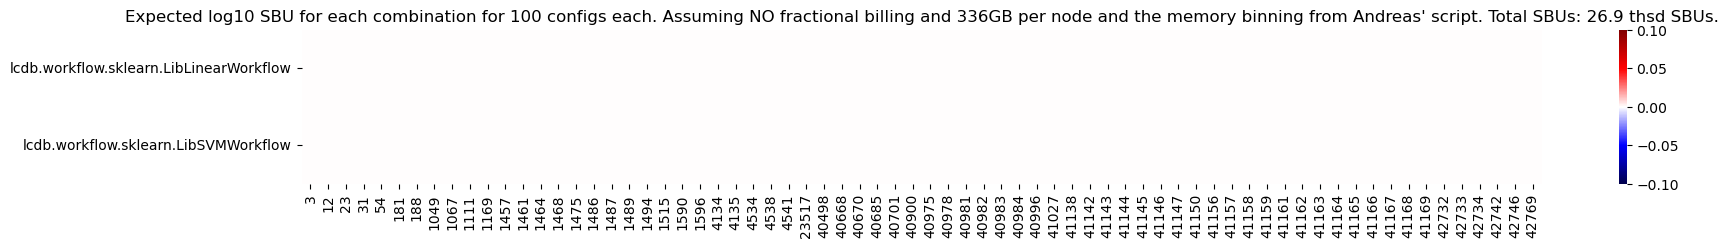

Overall expected node hours for 1 test seeds, 1 validation seeds, 1 workflow seeds, and 100 configs overall is 0.7 thsd hours
	Overall expected node hours for lcdb.workflow.sklearn.LibLinearWorkflow is 4.4 k hours
	Overall expected node hours for lcdb.workflow.sklearn.LibSVMWorkflow is 4.5 k hours


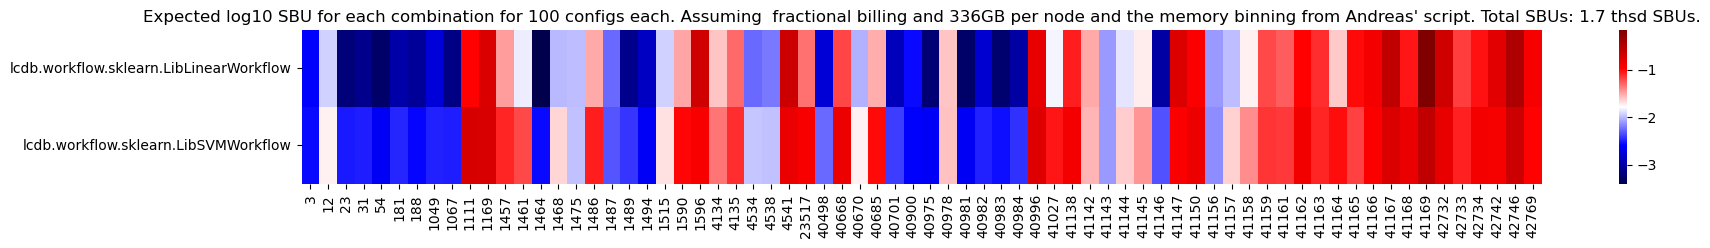

In [35]:
max_memory_per_node_in_gb = 336
sbus_per_node_hours = 192

parallel_jobs_per_combo = max_memory_per_node_in_gb / memory_bin_matrix
for fractional_billing in [False, True]:
    required_node_hours = expected_overall_runtimes_in_h / parallel_jobs_per_combo
    if not fractional_billing:
        required_node_hours = np.ceil(required_node_hours)
    sbus_overall = sbus_per_node_hours * required_node_hours.sum(axis=1)

    print(f"Overall expected node hours for {NUM_TEST_SEEDS_TO_EXTRAPOLATE_TO} test seeds, {NUM_VALID_SEEDS_TO_EXTRAPOLATE_TO} validation seeds, {NUM_WORKFLOW_SEEDS_TO_EXTRAPOLATE_TO} workflow seeds, and {NUM_CONFIGS_TO_EXTRAPOLATE_TO} configs overall is {np.round(np.sum(expected_overall_runtimes_in_h) / 10**3, 1)} thsd hours")
    for i, workflow in enumerate(d_workflows):
        print(f"\tOverall expected node hours for {workflow} is {np.round(np.sum(required_node_hours[i]), 1)} k hours")


    fig, ax = plt.subplots(1, 1, figsize=(20, 2))
    sb.heatmap(np.log10(required_node_hours), ax=ax, cmap="seismic")
    ax.set_xticklabels(d_datasets, rotation=90)
    ax.set_yticklabels(d_workflows, rotation=0)
    ax.set_title(f"Expected log10 SBU for each combination for {NUM_CONFIGS_TO_EXTRAPOLATE_TO} configs each. Assuming {'' if fractional_billing else 'NO'} fractional billing and {max_memory_per_node_in_gb}GB per node and the memory binning from Andreas' script. Total SBUs: {np.round(sbus_overall.sum() / 10**3, 1)} thsd SBUs.")  
    plt.show()